### Custom CNN - Version 3 - Deep model

In [38]:
from pathlib import Path
import pandas as pd
import os
import shutil
import hashlib
import seaborn as sns
from IPython.display import display
import time
import sys
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.models import resnet34, ResNet34_Weights
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import matthews_corrcoef

In [3]:
print(sys.executable)

/opt/anaconda3/envs/t3_project/bin/python


In [7]:
os.getcwd()

'/Users/kalyanivenkateswaran/Documents/T3_Project/waste_classification/notebooks'

In [8]:
os.getcwd()
os.chdir("..")
os.getcwd()

'/Users/kalyanivenkateswaran/Documents/T3_Project/waste_classification'

In [9]:
BASE_DIR = Path.cwd()
META_DIR = BASE_DIR / "data" / "metadata"
file1=META_DIR/"consolidated_metatdata.csv"

In [10]:
metadata_df = pd.read_csv(file1)

In [11]:
train_df, temp_df = train_test_split(
    metadata_df,
    test_size=0.30,          # 70 train / 30 temp
    stratify=metadata_df["stage2_label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,          # 15 / 15
    stratify=temp_df["stage2_label"],
    random_state=42
)

In [12]:
metadata_df.loc[metadata_df["filepath"].isin(train_df["filepath"]), "split"] = "train"
metadata_df.loc[metadata_df["filepath"].isin(test_df["filepath"]), "split"] = "test"
metadata_df.loc[metadata_df["filepath"].isin(val_df["filepath"]), "split"] = "val"

In [16]:
val_df = metadata_df.loc[metadata_df['split'] == "val"]
val_df["dup_flag"] = 0

test_df = metadata_df.loc[metadata_df['split'] == "test"]
test_df["dup_flag"] = 0

organic_df = metadata_df.loc[ (metadata_df['stage1_label'] == "Organic") & (metadata_df['split'] == "train") ]
organic_df["dup_flag"] = 0

# Duplicate
organic_dup = organic_df.copy()
organic_dup["dup_flag"] = 1

nonorganic_df = metadata_df.loc[(metadata_df['stage1_label'] == "Non_Organic") & (metadata_df['split'] == "train")]
nonorganic_df["dup_flag"] = 0

/var/folders/00/3779gmxd3l757wrbnsy_pcmc0000gn/T/ipykernel_29203/2872029741.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df["dup_flag"] = 0
/var/folders/00/3779gmxd3l757wrbnsy_pcmc0000gn/T/ipykernel_29203/2872029741.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["dup_flag"] = 0
/var/folders/00/3779gmxd3l757wrbnsy_pcmc0000gn/T/ipykernel_29203/2872029741.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

In [17]:
updated_metadata_df = pd.concat(
    [organic_df, organic_dup, nonorganic_df,val_df, test_df],
    ignore_index=True
).sample(frac=1)

In [19]:
updated_metadata_df['stage1_label'].value_counts()

stage1_label
Non_Organic    47681
Organic        33872
Name: count, dtype: int64

### Define transforms

In [22]:
train_transforms = {
    "non_organic": transforms.Compose([
    transforms.Resize((150,150)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    ]), 
    "org_base":transforms.Compose([
    transforms.Resize((150,150)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    ]),
    "org_dup":transforms.Compose([
    transforms.RandomResizedCrop(150, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.4
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    ])
}

In [23]:
val_transform = {
    
    "default": transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
   ])
}

### Custom waste dataset to read from metadata

In [24]:
# Define custom Dataset -> this will help you load images from your csv file
from torch.utils.data import Dataset
from PIL import Image

class CustomWasteData(Dataset):
    def __init__(self, csv_df, split,label_col, transforms_dict,train=True):
        self.df = csv_df
        self.df = self.df[self.df["split"] == split].reset_index(drop=True)
        
        #self.transform = transform
        self.label_col = label_col
        self.transforms_dict = transforms_dict
        self.train = train
        
        self.classes = sorted(self.df[label_col].unique())
        self.class_to_idx = {
            cls: i for i, cls in enumerate(self.classes)
        }

    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["filepath"]).convert("RGB")
        label = self.class_to_idx[row[self.label_col]]
        source = row["source"]     
        type_image = row["type"]    

        if self.train:
            if row["stage1_label"] == "Organic":
               if row["dup_flag"] == 1:
                   img = self.transforms_dict["org_dup"](img)
               else:
                   img = self.transforms_dict["org_base"](img)

            else:
                img = self.transforms_dict["non_organic"](img)
        else:
            img = self.transforms_dict["default"](img)

        return img, label, source, type_image

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)

In [ ]:
class ResidualBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = torch.nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = torch.nn.BatchNorm2d(out_channels)
        self.conv2 = torch.nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = torch.nn.BatchNorm2d(out_channels)
        self.activation = torch.nn.LeakyReLU(0.1)
        
        self.shortcut = torch.nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = torch.nn.Sequential(
                torch.nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                torch.nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.activation(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.activation(out)
        return out

In [ ]:
class CNN_stage1_res(torch.nn.Module):
    def __init__(self, num_classes=2):
        super(CNN_stage1_res, self).__init__()
        self.in_channels = 32
        #self.conv1 = torch.nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        #self.bn1 = torch.nn.BatchNorm2d(32)
        #self.relu = torch.nn.LeakyReLU(0.1)
        
        self.initialconv = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, kernel_size=3, padding=1,bias=False),
            torch.nn.BatchNorm2d(32),
            torch.nn.LeakyReLU(0.1)
        )
        
        self.layer1 = self._make_layer(ResidualBlock, 64, 1, stride=1)
        self.layer2 = self._make_layer(ResidualBlock, 128, 1, stride=2)
        self.layer3 = self._make_layer(ResidualBlock, 256, 1, stride=2)
        self.layer4 = self._make_layer(ResidualBlock, 256, 1, stride=2)

        self.avgpool = torch.nn.AdaptiveAvgPool2d((1, 1))
        # Dense layers
        self.fc1 = torch.nn.Linear(256, 512)
        self.dropout = torch.nn.Dropout(0.5)
        self.fc2 = torch.nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return torch.nn.Sequential(*layers)

    def forward(self, x):
        F = torch.nn.functional
        out = self.initialconv(x)
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)

        out = self.fc1(out)
        out = F.leaky_relu(out,0.1)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out



### Data Loaders

In [25]:
# Creating datasets - Stage 1 
train_ds_stage1 = CustomWasteData(
    updated_metadata_df,
    split="train",
    label_col="stage1_label",
    transforms_dict=train_transforms,
    train=True
)

val_ds_stage1 = CustomWasteData(
    updated_metadata_df,
    split="val",
    label_col="stage1_label",
    transforms_dict=val_transform,
    train=False
)

In [28]:
from torch.utils.data import DataLoader

train_loader_s1 = DataLoader(
    train_ds_stage1,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader_s1 = DataLoader(
    val_ds_stage1,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


In [169]:
#device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device("mps")
CNN_stage1_res_model = CNN_stage1_res(2).to(device)

num_epochs = 20
learning_rate = 0.0001
weight_decay = 0.01
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.NAdam(
    CNN_stage1_res_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)
early_stopping = EarlyStopping(patience=5, delta=0.01)

In [170]:
# Training loop
epoch_times = []
train_acc_list = []
train_loss_list = []
val_acc_list = []
val_loss_list= []
for epoch in range(num_epochs):
    start = time.time()
    CNN_stage1_res_model.train()
    running_loss = 0.0
    train_loss = 0.0
    train_accuracy = 0.0
    all_predictions = []
    all_labels = []
    for images, labels, sources, type_images in train_loader_s1:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = CNN_stage1_res_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # Average loss and accuracy
    train_loss = running_loss / len(train_loader_s1)
    train_accuracy = 100 * sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)

    train_loss_list.append(train_loss)
    train_acc_list.append(train_accuracy)
        
    end = time.time()
    epoch_time = end - start
    epoch_times.append(epoch_time)

    print(f"Epoch {epoch+1} time: {epoch_time:.2f} sec")
    print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {train_loss:.4f}')
    print(f'Epoch [{epoch+1}/{num_epochs}], Training Accuracy: {train_accuracy:.4f}')
    
    scheduler.step() # for LR scheduler
    
    CNN_stage1_res_model.eval()
    all_predictions = []
    all_labels = []
    running_loss = 0.0
    val_loss = 0.0
    val_accuracy = 0.0
    with torch.no_grad():
        for images, labels, sources, type_images in val_loader_s1:
            images = images.to(device)
            labels = labels.to(device)
            outputs = CNN_stage1_res_model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(val_loader_s1)
    val_accuracy = 100 * sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)

    val_loss_list.append(val_loss)
    val_acc_list.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss:.4f}')
    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Accuracy: {val_accuracy:.4f}')

    early_stopping(val_loss, CNN_stage1_res_model)
    if early_stopping.early_stop:
        print("Early stopping")
        break
    print('-----------------------------')

early_stopping.load_best_model(CNN_stage1_res_model)
total_time = sum(epoch_times)
print(f"Total training time: {total_time/60:.2f} minutes")


/opt/anaconda3/envs/t3_project/lib/python3.11/site-packages/PIL/Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1 time: 1113.02 sec
Epoch [1/20], Training Loss: 0.3874
Epoch [1/20], Training Accuracy: 83.4196
Epoch [1/20], Validation Loss: 0.4613
Epoch [1/20], Validation Accuracy: 79.6470
-----------------------------
Epoch 2 time: 1112.63 sec
Epoch [2/20], Training Loss: 0.3315
Epoch [2/20], Training Accuracy: 86.2904
Epoch [2/20], Validation Loss: 0.3410
Epoch [2/20], Validation Accuracy: 85.5931
-----------------------------
Epoch 3 time: 1113.81 sec
Epoch [3/20], Training Loss: 0.3067
Epoch [3/20], Training Accuracy: 87.5537
Epoch [3/20], Validation Loss: 0.3296
Epoch [3/20], Validation Accuracy: 86.3426
-----------------------------
Epoch 4 time: 1111.73 sec
Epoch [4/20], Training Loss: 0.2931
Epoch [4/20], Training Accuracy: 88.1314
Epoch [4/20], Validation Loss: 0.3000
Epoch [4/20], Validation Accuracy: 88.6303
-----------------------------
Epoch 5 time: 1114.23 sec
Epoch [5/20], Training Loss: 0.2833
Epoch [5/20], Training Accuracy: 88.6194
Epoch [5/20], Validation Loss: 0.3501
Epo

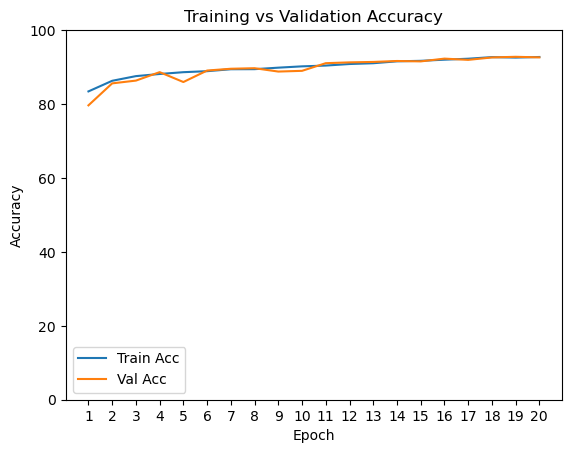

In [171]:
epochs = range(1, num_epochs +1)
plt.title('Training vs Validation Accuracy')
plt.plot(epochs,train_acc_list, label="Train Acc")
plt.plot(epochs,val_acc_list, label="Val Acc")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.ylim(0, 100)
plt.legend()
plt.show()

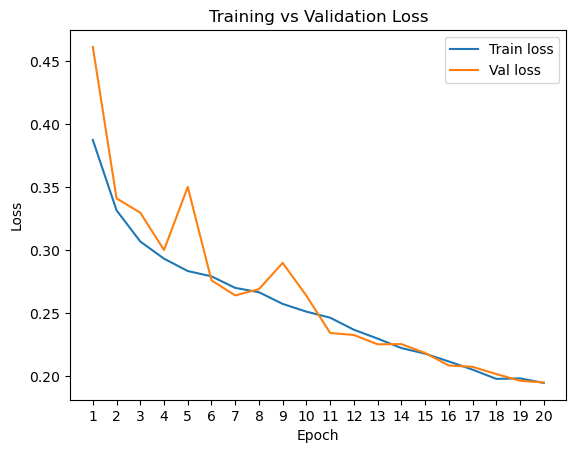

In [172]:
epochs = range(1, num_epochs + 1)
plt.title('Training vs Validation Loss')
plt.plot(epochs,train_loss_list, label="Train loss")
plt.plot(epochs,val_loss_list, label="Val loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.show()

In [174]:
# Validation
CNN_stage1_res_model.eval()
all_predictions = []
all_labels = []
start = time.time()
with torch.no_grad():
    for images, labels, sources, type_images in val_loader_s1:
        images = images.to(device)
        labels = labels.to(device)
        outputs = CNN_stage1_res_model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

end = time.time()
num_images= len(val_loader_s1.dataset)
avg_time = (end - start) / num_images
throughput = num_images / (end - start)

print(f"Inference time per image: {avg_time*1000:.2f} ms")
print(f"Throughput: {throughput:.2f} images/sec")

# Calculate metrics
accuracy = 100 * sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')
balanced_acccuracy=100 * balanced_accuracy_score(all_labels, all_predictions)
mcc = matthews_corrcoef(all_labels, all_predictions)

print(f'Accuracy on test set: {accuracy:.2f}%')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Balanced Accuracy on test set: {balanced_acccuracy:.2f}%')
print(f'MCC is: {mcc:.2f}')
print('-----------------------------')

/opt/anaconda3/envs/t3_project/lib/python3.11/site-packages/PIL/Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Inference time per image: 6.50 ms
Throughput: 153.84 images/sec
Accuracy on test set: 92.62%
Precision: 0.9257
Recall: 0.9262
F1 Score: 0.9258
Balanced Accuracy on test set: 90.57%
MCC is: 0.82
-----------------------------


              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7152
           1       0.89      0.86      0.87      2989

    accuracy                           0.93     10141
   macro avg       0.92      0.91      0.91     10141
weighted avg       0.93      0.93      0.93     10141



[Text(0, 0.5, 'Organic'), Text(0, 1.5, 'Non-Organic')]

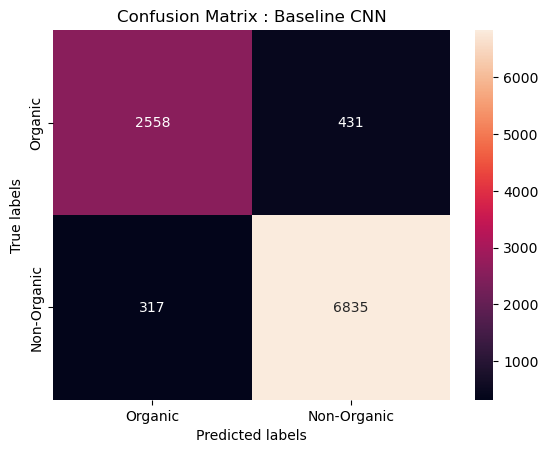

In [186]:
cm = confusion_matrix(all_labels, all_predictions, labels=[1,0])
print(classification_report(all_labels, all_predictions))

ax= plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax);

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix : Baseline CNN'); 
ax.xaxis.set_ticklabels(['Organic', 'Non-Organic']); ax.yaxis.set_ticklabels(['Organic', 'Non-Organic'])